In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# 0 = all messages are logged (default behavior)
# 1 = INFO messages are not printed
# 2 = INFO and WARNING messages are not printed
# 3 = INFO, WARNING, and ERROR messages are not printed

import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
#from google.colab import drive
#drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

import warnings
# https://stackoverflow.com/questions/15777951/how-to-suppress-pandas-future-warning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

import logging
tf.get_logger().setLevel(logging.ERROR)

# https://stackoverflow.com/questions/65697623/tensorflow-warning-found-untraced-functions-such-as-lstm-cell-6-layer-call-and
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

# Data Cleansing, Normalization and Feature Engineering

In [2]:
df = pd.read_csv('merged_1.dat', sep=",", parse_dates=["Date"], index_col="Date")
df

,Ppt_x,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Ppt_y,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3,0.0,-1.090,81.50,1.052,52.27,0.63
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3,0.0,-1.038,81.70,0.959,46.71,0.62
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3,0.0,-0.981,82.00,1.062,52.04,0.60
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3,0.0,-0.814,81.90,0.887,58.91,0.64
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3,0.0,-0.805,90.00,0.828,16.55,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,0.097,0.104,0.104,0.106,34.60,34.71,33.68,29.86,0,0.0,29.100,60.19,0.610,197.10,0.00
2021-08-31 21:00:00,0.0,0.097,0.103,0.104,0.106,33.58,34.07,33.50,29.95,0,0.0,28.070,62.28,0.510,199.60,0.00
2021-08-31 22:00:00,0.0,0.096,0.103,0.103,0.106,32.75,33.46,33.23,30.03,0,0.0,27.730,63.98,1.417,192.60,0.00


In [3]:
# convert wind velocity and wind direction to a wind vector
wv = df.pop('Windspeed')

# Convert to radians.
wd_rad = df.pop('Winddirection')*np.pi / 180

# Calculate the wind x and y components.
df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)


# Time Conversion

timestamp_s = (df.index).map(pd.Timestamp.timestamp)
day = 24*60*60
year = (365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))


# Flag is not needed
df.pop('Flag')

# create one standard metric for temperature
# df['PPT'] = (df.pop('Ppt_x') + df.pop('Ppt_y'))/2
# df
df.pop('Ppt_y')

df = df.rename(columns={'Ppt_x': 'PPT'})

# Drop the None values
df = df.dropna()

df

,PPT,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos
Date,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.50,0.63,0.643762,0.832030,1.232357e-12,1.000000,0.001505,0.999999
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.70,0.62,0.657578,0.698049,2.588190e-01,0.965926,0.002222,0.999998
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.00,0.60,0.653248,0.837324,5.000000e-01,0.866025,0.002939,0.999996
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.90,0.64,0.458032,0.759589,7.071068e-01,0.707107,0.003656,0.999993
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.00,0.20,0.793697,0.235857,8.660254e-01,0.500000,0.004372,0.999990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,0.097,0.104,0.104,0.106,34.60,34.71,33.68,29.86,29.100,60.19,0.00,-0.583034,-0.179365,-8.660254e-01,0.500000,-0.865774,-0.500434
2021-08-31 21:00:00,0.0,0.097,0.103,0.104,0.106,33.58,34.07,33.50,29.95,28.070,62.28,0.00,-0.480449,-0.171080,-7.071068e-01,0.707107,-0.866133,-0.499814
2021-08-31 22:00:00,0.0,0.096,0.103,0.103,0.106,32.75,33.46,33.23,30.03,27.730,63.98,0.00,-1.382874,-0.309109,-5.000000e-01,0.866025,-0.866491,-0.499193


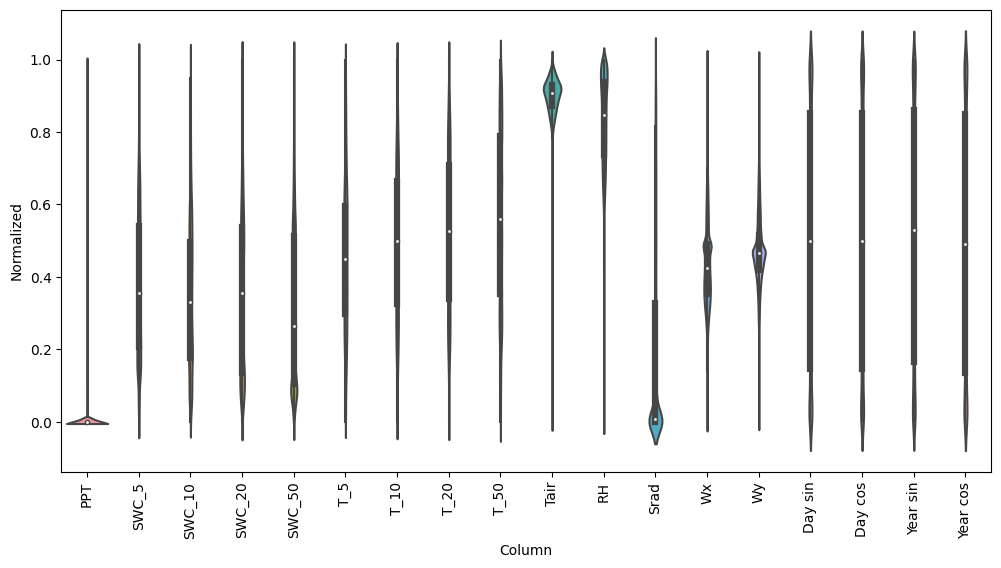

In [4]:
# Min-max Normalization of this data
df_max = df.max()
df_min = df.min()

norm_df = (df - df_min ) / (df_max -  df_min)



# df_std = (df - train_mean) / train_std
df_melted = norm_df.melt(var_name='Column', value_name='Normalized')


plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_melted)
_ = ax.set_xticklabels(df.keys(), rotation=90)

# Data Batch Generation


In [5]:
# Single step Batch generator
def batch_generator(df, label_column, window_size=0, label_shift=0):

    label_col = df[label_column].to_numpy()
    df_as_np = df.to_numpy()

    X = []
    y = []
    for i in range(len(df_as_np) - window_size - label_shift):
        row = [a for a in df_as_np[i:i+window_size]]
        X.append(row)
        label = label_col[i + window_size + label_shift]
        y.append(label)
    return np.array(X), np.array(y)



In [6]:
WINDOW_SIZE = 24*14
label_shift = 24*1
X1, y1 = batch_generator(norm_df,'SWC_5', WINDOW_SIZE, label_shift)


In [7]:
# (batch, time, features)
X1.shape, y1.shape

((57226, 336, 18), (57226,))

# Modeling

In [8]:
# One year validation
# One year testing
# 365*24 is one year

X_train1, y_train1 = X1[:len(X1) - 365*24*2], y1[:len(X1) - 365*24*2]
X_val1, y_val1 = X1[len(X_train1):len(X_train1) + 365*24], y1[len(X_train1):len(X_train1) + 365*24]
X_test1, y_test1 = X1[len(X_train1)+ 365*24:len(X_train1) + 2* 365*24], y1[len(X_train1)+ 365*24:len(X_train1) + 2*365*24]
X1.shape, y1.shape, X_train1.shape, y_train1.shape, X_val1.shape, y_val1.shape, X_test1.shape, y_test1.shape

((57226, 336, 18),
 (57226,),
 (39706, 336, 18),
 (39706,),
 (8760, 336, 18),
 (8760,),
 (8760, 336, 18),
 (8760,))

In [9]:
from tensorflow import keras

from keras.models import Sequential
from keras.layers import  *
from keras.layers import  InputLayer
from keras.callbacks import ModelCheckpoint
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam

model1 = Sequential()

model1.add(InputLayer((WINDOW_SIZE, 18)))
# model1.add(LSTM(64))

# model1.add(Activation('elu'))
# model1.add(Dense(1, activation='relu'))

model1.add(LSTM(128, return_sequences=True))
model1.add(LSTM(64))
model1.add(Dense(16, 'relu'))
model1.add(Dense(1, 'relu'))

model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 336, 128)          75264     
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 16)                1040      
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 125,729
Trainable params: 125,729
Non-trainable params: 0
_________________________________________________________________


In [10]:
MAX_EPOCHS = 100
# patience	Number of epochs with no improvement after which training will be stopped.

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=3,
                                                    mode='min')

cp1 = ModelCheckpoint('model1/', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [11]:
# https://stackoverflow.com/questions/64159777/stateful-lstm-tensorflow-invalid-input-h-shape-error

# BATCH_SIZE = 64
# steps_per_epoch = len(X_train1) // BATCH_SIZE
# print("steps_per_epoch:", steps_per_epoch)

model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1),
           epochs=MAX_EPOCHS,
          #  steps_per_epoch = steps_per_epoch,
           callbacks=[cp1, early_stopping])

Epoch 1/100
1241/1241 [==============================] - 49s 33ms/step - loss: 0.0097 - root_mean_squared_error: 0.0985 - val_loss: 0.0084 - val_root_mean_squared_error: 0.0915
Epoch 2/100
1241/1241 [==============================] - 30s 24ms/step - loss: 0.0074 - root_mean_squared_error: 0.0859 - val_loss: 0.0086 - val_root_mean_squared_error: 0.0925
Epoch 3/100
1241/1241 [==============================] - 29s 24ms/step - loss: 0.0071 - root_mean_squared_error: 0.0841 - val_loss: 0.0088 - val_root_mean_squared_error: 0.0938
Epoch 4/100
1241/1241 [==============================] - 30s 25ms/step - loss: 0.0068 - root_mean_squared_error: 0.0824 - val_loss: 0.0085 - val_root_mean_squared_error: 0.0922


In [12]:
from keras.models import load_model
model1 = load_model('model1/')

In [13]:
# train_predictions = model1.predict(X_train1).flatten()
# train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train1})

# plt.plot(train_results['Train Predictions'])
# plt.plot(train_results['Actuals'])

In [14]:
# test_predictions = model1.predict(X_test1).flatten()
# test_results = pd.DataFrame(data={'Train Predictions':test_predictions, 'Actuals':y_test1})

# plt.plot(test_results['Train Predictions'])
# plt.plot(test_results['Actuals'])

In [15]:
from sklearn.metrics import mean_squared_error as mse

def plot_predictions1(model, X, y):
    predictions = model.predict(X).flatten()

    df = pd.DataFrame(data={'Predictions':predictions, 'Actuals':y})

    plt.plot(df['Predictions'])
    plt.plot(df['Actuals'])
    plt.legend(('Predictions', 'Actuals'))



    return df, mse(y, predictions)

274/274 [==============================] - 4s 10ms/step
MSE is: 0.010056612569082767


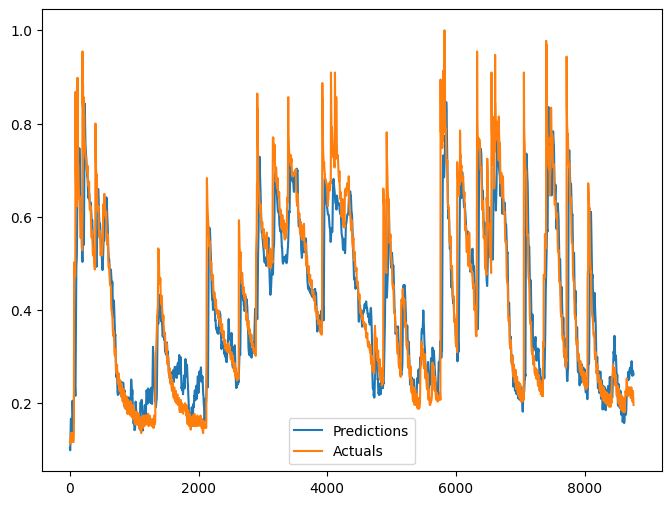

In [16]:
_, mse = plot_predictions1(model1, X_test1, y_test1)

print("MSE is:", mse)